#### Part 2: Data Inspection

In [34]:
#import necessary package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# import/load the right dataset. Since the dataset is related to heart disease prediction, so I will call the dataset hdp

hdp = pd.read_csv("C:/Users/HP/Downloads/Heart Disease project/heart.csv")


# Inspect initial shape and first 10 rows
print(f"Dataset Shape: {hdp.shape}")
hdp.head(10)

Dataset Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


### Let's examine the dataset

In [35]:
# Data structure

print("\nDataset Structure:")
print(hdp.info())


Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [36]:
#  no of rows and columns
print("\nNumber of Rows and Columns:")
print(f"Rows: {hdp.shape[0]}")
print(f"Columns: {hdp.shape[1]}")



Number of Rows and Columns:
Rows: 918
Columns: 12


In [37]:
# Display data types
print("\nData Types:")
display(hdp.dtypes)


Data Types:


Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [38]:
# I'm checking for missing values
print("\nMissing Values:")
missing_values = hdp.isnull().sum()
display(missing_values)


Missing Values:


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [39]:
# Is there any duplicate records at all?
print("\nNo of Duplicate Records:")
print(hdp.duplicated().sum())



No of Duplicate Records:
0


In [40]:
# My summary statistics for numerical variables
print("\nSummary Statistics – Numerical Variables:")
display(hdp.describe())


Summary Statistics – Numerical Variables:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


#### Part 3 – Feature Engineering & Data Preprocessing

In [41]:
# duplicate a copy for preprocessing
clean_hdp = hdp.copy()
clean_hdp

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [42]:
print("Missing values before cleaning:")
display(clean_hdp.isnull().sum())

Missing values before cleaning:


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [43]:
# Handling missing values
# Numerical columns: replace missing values with the median
numerical_columns = clean_hdp.select_dtypes(include=np.number).columns

for column in numerical_columns:
    if clean_hdp[column].isnull().sum() > 0:
        clean_hdp[column] = clean_hdp[column].fillna(clean_hdp[column].median())

# Categorical columns: replace missing values with the mode
categorical_columns = clean_hdp.select_dtypes(include="object").columns

for column in categorical_columns:
    if clean_hdp[column].isnull().sum() > 0:
        clean_hdp[column] = clean_hdp[column].fillna(clean_hdp[column].mode()[0])

print("\nMissing values after cleaning:")
display(clean_hdp.isnull().sum())



Missing values after cleaning:


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [44]:
# Checking for duplicate records and removing them

duplicates_before = clean_hdp.duplicated().sum()

print(f"\nDuplicate records before removal: {duplicates_before}")

clean_hdp = clean_hdp.drop_duplicates().reset_index(drop=True)

duplicates_after = clean_hdp.duplicated().sum()

print(f"Duplicate records after removal: {duplicates_after}")


Duplicate records before removal: 0
Duplicate records after removal: 0


In [45]:
# Decision: Each patient should only count once so the data stays balanced.
#Avoids model bias: If the AI sees the same information repeated, it gets overly focused on those specific cases instead of learning the bigger picture.

In [46]:
# Convert numerical columns to numeric data types
numeric_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "HeartDisease"
]

for col in numeric_columns:
    hdp[col] = pd.to_numeric(hdp[col], errors="coerce")

# Convert categorical variables to category type
categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for col in categorical_columns:
    hdp[col] = hdp[col].astype("category")

# Check data types
display(hdp.dtypes)

Age                  int64
Sex               category
ChestPainType     category
RestingBP            int64
Cholesterol          int64
FastingBS            int64
RestingECG        category
MaxHR                int64
ExerciseAngina    category
Oldpeak            float64
ST_Slope          category
HeartDisease         int64
dtype: object

In [47]:
# Decision: Numerical variables must be stored as numerical values so mathematical operations and scaling can be performed correctly. 
#Categorical variables are converted to the category data type to clearly distinguish them from continuous numerical features.

#### Feature Engineering

In [48]:
# Creating a useful feature for AgeGroup, which groups patients into broad age categories.

hdp["AgeGroup"] = pd.cut(
    hdp["Age"],
    bins=[0, 39, 49, 59, 69, 100],
    labels=["<40", "40-49", "50-59", "60-69", "70+"]
)

display(hdp[["Age", "AgeGroup"]].head(10))

,Age,AgeGroup
0,40,40-49
1,49,40-49
2,37,<40
3,48,40-49
4,54,50-59
5,39,<40
6,45,40-49
7,54,50-59
8,37,<40
9,48,40-49


In [49]:
# Broad trends: Grouping ages helps the AI spot general risk patterns across life stages.
#Exact detail: Exact age already gives precise data down to the year.

#The decision: We'll compare model performance with and without age brackets to see if grouping actually improves accuracy.

In [50]:
#Rename Columns for Clarity
# Rename columns for consistency and clarity
hdp = hdp.rename(columns={
    "Age": "age",
    "Sex": "sex",
    "ChestPainType": "chest_pain_type",
    "RestingBP": "resting_bp",
    "Cholesterol": "cholesterol",
    "FastingBS": "fasting_blood_sugar",
    "RestingECG": "resting_ecg",
    "MaxHR": "max_heart_rate",
    "ExerciseAngina": "exercise_angina",
    "Oldpeak": "oldpeak",
    "ST_Slope": "st_slope",
    "HeartDisease": "heart_disease",
    "AgeGroup": "age_group"
})

display(hdp.head(10))

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,heart_disease,age_group
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,40-49
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,40-49
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,<40
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,40-49
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,50-59
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0,<40
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0,40-49
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0,50-59
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1,<40
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0,40-49


In [51]:
#Decision: Programming tools can get confused by spaces or weird capitalization. 
#Standardizing the names prevents bugs and makes writing code much faster.

In [52]:
# Feature Encoding
# One-hot encode nominal is suitable for categorical variables because their categories are nominal and have no meaningful order.
one_hot_columns = [
    "chest_pain_type",
    "resting_ecg"
]

hdp_encoded = pd.get_dummies(
    hdp,
    columns=one_hot_columns,
    drop_first=True,
    dtype=int
)

display(hdp_encoded.head(10))

,age,sex,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_angina,oldpeak,st_slope,heart_disease,age_group,chest_pain_type_ATA,chest_pain_type_NAP,chest_pain_type_TA,resting_ecg_Normal,resting_ecg_ST
0,40,M,140,289,0,172,N,0.0,Up,0,40-49,1,0,0,1,0
1,49,F,160,180,0,156,N,1.0,Flat,1,40-49,0,1,0,1,0
2,37,M,130,283,0,98,N,0.0,Up,0,<40,1,0,0,0,1
3,48,F,138,214,0,108,Y,1.5,Flat,1,40-49,0,0,0,1,0
4,54,M,150,195,0,122,N,0.0,Up,0,50-59,0,1,0,1,0
5,39,M,120,339,0,170,N,0.0,Up,0,<40,0,1,0,1,0
6,45,F,130,237,0,170,N,0.0,Up,0,40-49,1,0,0,1,0
7,54,M,110,208,0,142,N,0.0,Up,0,50-59,1,0,0,1,0
8,37,M,140,207,0,130,Y,1.5,Flat,1,<40,0,0,0,1,0
9,48,F,120,284,0,120,N,0.0,Up,0,40-49,1,0,0,1,0


In [53]:
# Binary encoding

hdp_encoded["sex"] = hdp_encoded["sex"].map({
    "M": 1,
    "F": 0
})

hdp_encoded["exercise_angina"] = hdp_encoded["exercise_angina"].map({
    "Y": 1,
    "N": 0
})

# Encode ST slope
hdp_encoded["st_slope"] = hdp_encoded["st_slope"].map({
    "Up": 0,
    "Flat": 1,
    "Down": 2
})

# Convert boolean columns created by get_dummies to integers
boolean_columns = hdp_encoded.select_dtypes(include="bool").columns

hdp_encoded[boolean_columns] = hdp_encoded[boolean_columns].astype(int)

display(hdp_encoded.head(10))

,age,sex,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_angina,oldpeak,st_slope,heart_disease,age_group,chest_pain_type_ATA,chest_pain_type_NAP,chest_pain_type_TA,resting_ecg_Normal,resting_ecg_ST
0,40,1,140,289,0,172,0,0.0,0,0,40-49,1,0,0,1,0
1,49,0,160,180,0,156,0,1.0,1,1,40-49,0,1,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,<40,1,0,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,40-49,0,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,50-59,0,1,0,1,0
5,39,1,120,339,0,170,0,0.0,0,0,<40,0,1,0,1,0
6,45,0,130,237,0,170,0,0.0,0,0,40-49,1,0,0,1,0
7,54,1,110,208,0,142,0,0.0,0,0,50-59,1,0,0,1,0
8,37,1,140,207,0,130,1,1.5,1,1,<40,0,0,0,1,0
9,48,0,120,284,0,120,0,0.0,0,0,40-49,1,0,0,1,0


In [54]:
#To handle categorical variables properly, we use one-hot encoding for chest_pain_type and resting_ecg because their values are strictly 
#nominal and lack an inherent ranking. For two-value variables like sex and exercise_angina, simple binary/label encoding is sufficient. 
#Finally, while ST_slope possesses an ordered clinical interpretation, mapping it numerically can introduce unwanted distance assumptions 
#into certain algorithms; using one-hot encoding here serves as a risk-free alternative.

In [55]:
# Feature Scaling

# Numerical features to scale
scaling_columns = [
    "age",
    "resting_bp",
    "cholesterol",
    "fasting_blood_sugar",
    "max_heart_rate",
    "oldpeak"
]
# Create scaler
scaler = StandardScaler()

# Apply standardization
hdp_encoded[scaling_columns] = scaler.fit_transform(
    hdp_encoded[scaling_columns]
)

# Display scaled variables
display(hdp_encoded[scaling_columns].head(10))

,age,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,oldpeak
0,-1.433140,0.410909,0.825070,-0.551341,1.382928,-0.832432
1,-0.478484,1.491752,-0.171961,-0.551341,0.754157,0.105664
2,-1.751359,-0.129513,0.770188,-0.551341,-1.525138,-0.832432
3,-0.584556,0.302825,0.139040,-0.551341,-1.132156,0.574711
4,0.051881,0.951331,-0.034755,-0.551341,-0.581981,-0.832432
5,-1.539213,-0.669935,1.282424,-0.551341,1.304332,-0.832432
6,-0.902775,-0.129513,0.349422,-0.551341,1.304332,-0.832432
7,0.051881,-1.210356,0.084157,-0.551341,0.203982,-0.832432
8,-1.751359,0.410909,0.075010,-0.551341,-0.267596,0.574711
9,-0.584556,-0.669935,0.779335,-0.551341,-0.660578,-0.832432


In [56]:
# I apply StandardScaler to re-center my numerical features around a mean of 0 with a standard deviation of 1. 
#Algorithms relying on distance calculations or gradient descent—like Logistic Regression, KNN, SVMs, and Neural Networks—can perform poorly 
#when inputs exist on wildly different scales. Standardizing ensures large-scale variables like cholesterol don't drown out smaller ones. 
#I leave our target variable, heart_disease, untouched because scaling classification labels isn't necessary. 
#Although tree-based models like Random Forests don't require feature scaling, using StandardScaler gives us a clean, 
#uniform foundation for comparing different algorithms side-by-side.

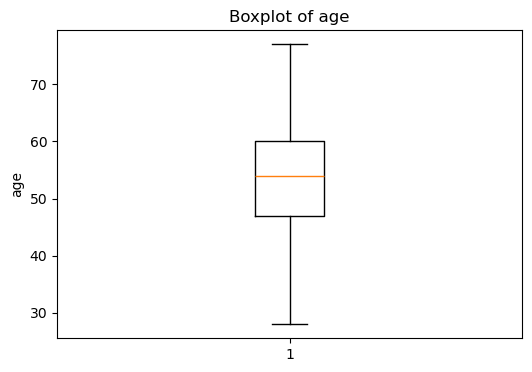

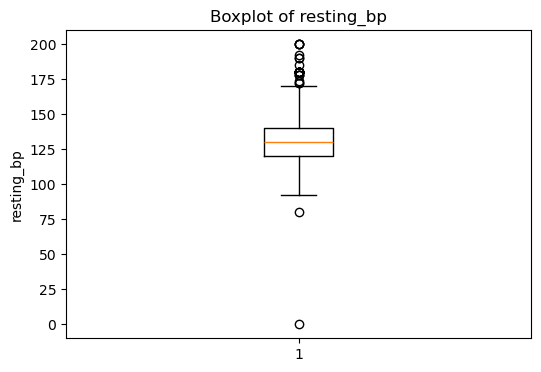

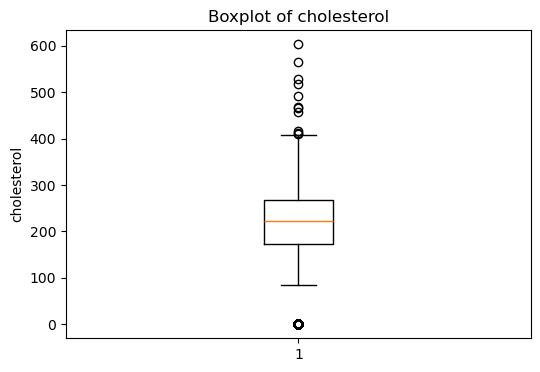

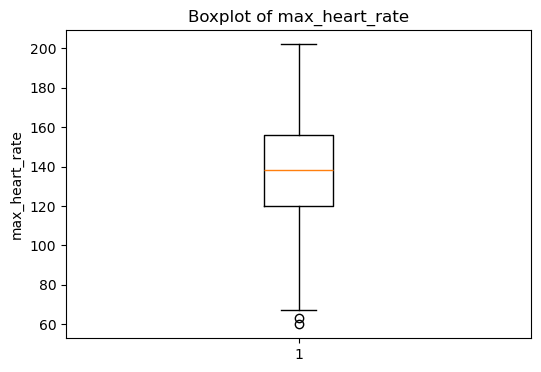

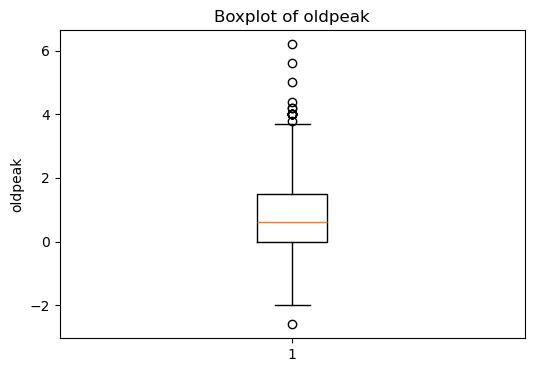

In [66]:
# Detecting Outlier from my data
outlier_columns = [
    "age",
    "resting_bp",
    "cholesterol",
    "max_heart_rate",
    "oldpeak"
]

# Create boxplots
for col in outlier_columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(hdp[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [67]:
# Check final dataset
print("Final dataset shape:", hdp_encoded.shape)

print("\nFinal data types:")
display(hdp_encoded.dtypes)

print("\nMissing values:")
display(hdp_encoded.isnull().sum())

print("\nDuplicate records:")
print(hdp_encoded.duplicated().sum())

print("\nFinal dataset:")
display(hdp_encoded.head(10))

Final dataset shape: (918, 16)

Final data types:


age                     float64
sex                    category
resting_bp              float64
cholesterol             float64
fasting_blood_sugar     float64
max_heart_rate          float64
exercise_angina        category
oldpeak                 float64
st_slope               category
heart_disease             int64
age_group              category
chest_pain_type_ATA       int32
chest_pain_type_NAP       int32
chest_pain_type_TA        int32
resting_ecg_Normal        int32
resting_ecg_ST            int32
dtype: object


Missing values:


age                    0
sex                    0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
heart_disease          0
age_group              0
chest_pain_type_ATA    0
chest_pain_type_NAP    0
chest_pain_type_TA     0
resting_ecg_Normal     0
resting_ecg_ST         0
dtype: int64


Duplicate records:
0

Final dataset:


,age,sex,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_angina,oldpeak,st_slope,heart_disease,age_group,chest_pain_type_ATA,chest_pain_type_NAP,chest_pain_type_TA,resting_ecg_Normal,resting_ecg_ST
0,-1.433140,1,0.410909,0.825070,-0.551341,1.382928,0,-0.832432,0,0,40-49,1,0,0,1,0
1,-0.478484,0,1.491752,-0.171961,-0.551341,0.754157,0,0.105664,1,1,40-49,0,1,0,1,0
2,-1.751359,1,-0.129513,0.770188,-0.551341,-1.525138,0,-0.832432,0,0,<40,1,0,0,0,1
3,-0.584556,0,0.302825,0.139040,-0.551341,-1.132156,1,0.574711,1,1,40-49,0,0,0,1,0
4,0.051881,1,0.951331,-0.034755,-0.551341,-0.581981,0,-0.832432,0,0,50-59,0,1,0,1,0
5,-1.539213,1,-0.669935,1.282424,-0.551341,1.304332,0,-0.832432,0,0,<40,0,1,0,1,0
6,-0.902775,0,-0.129513,0.349422,-0.551341,1.304332,0,-0.832432,0,0,40-49,1,0,0,1,0
7,0.051881,1,-1.210356,0.084157,-0.551341,0.203982,0,-0.832432,0,0,50-59,1,0,0,1,0
8,-1.751359,1,0.410909,0.075010,-0.551341,-0.267596,1,0.574711,1,1,<40,0,0,0,1,0
9,-0.584556,0,-0.669935,0.779335,-0.551341,-0.660578,0,-0.832432,0,0,40-49,1,0,0,1,0


#### Part 4 – Feature Selection

In [60]:
# Separate predictors and target
X = hdp_encoded.drop(columns=["heart_disease"])
y = hdp_encoded["heart_disease"]

print("Features:", X.columns.tolist())
print("\nTarget:", y.name)

Features: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope', 'age_group', 'chest_pain_type_ATA', 'chest_pain_type_NAP', 'chest_pain_type_TA', 'resting_ecg_Normal', 'resting_ecg_ST']

Target: heart_disease


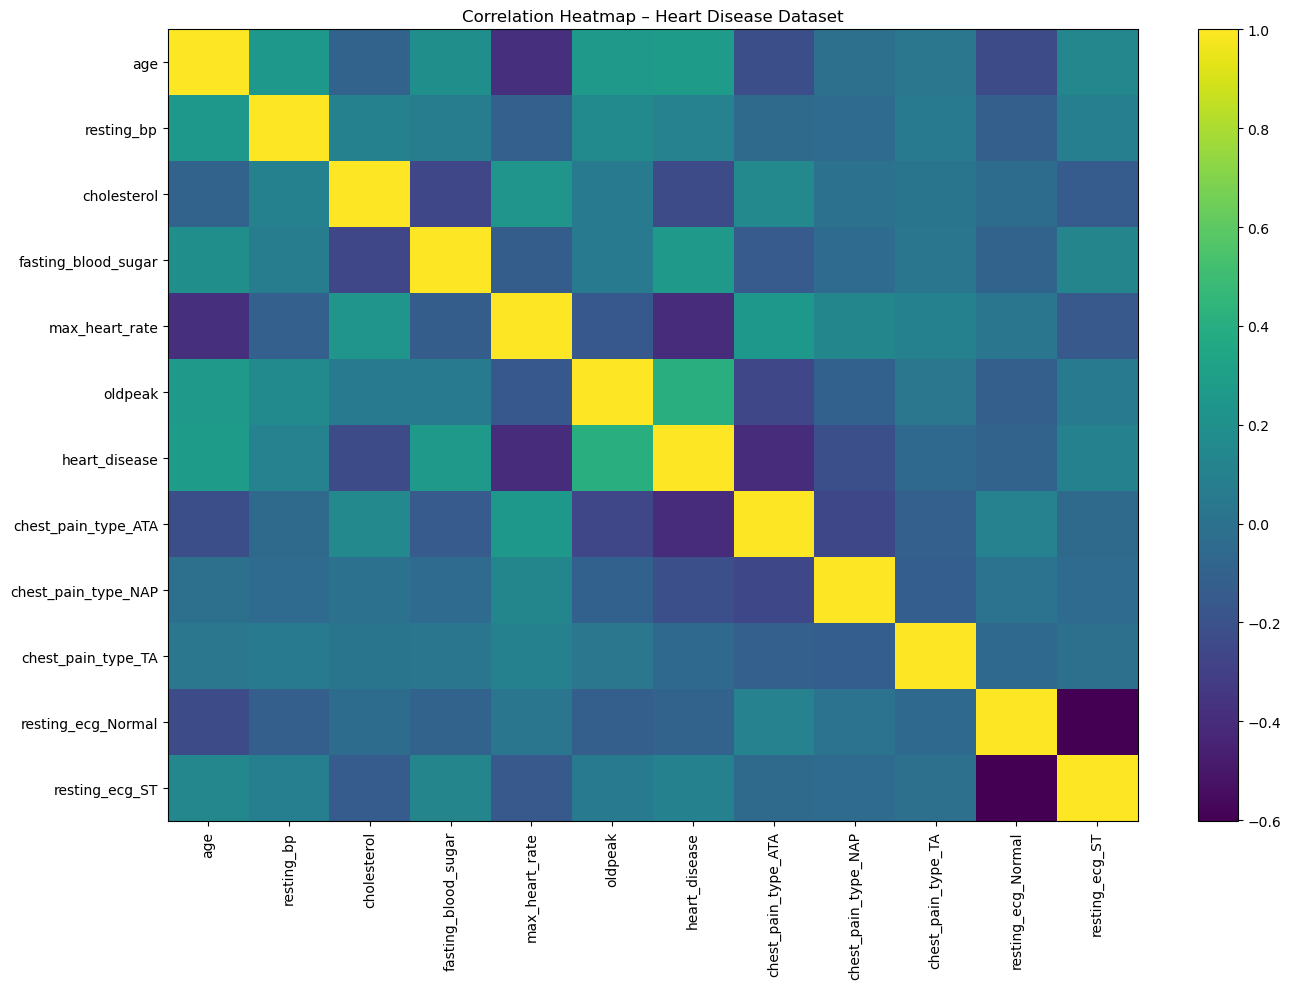

In [61]:
# Calculate correlation matrix
correlation_matrix = hdp_encoded.corr(numeric_only=True)

# Plot correlation heatmap
plt.figure(figsize=(14, 10))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap – Heart Disease Dataset")
plt.tight_layout()
plt.show()

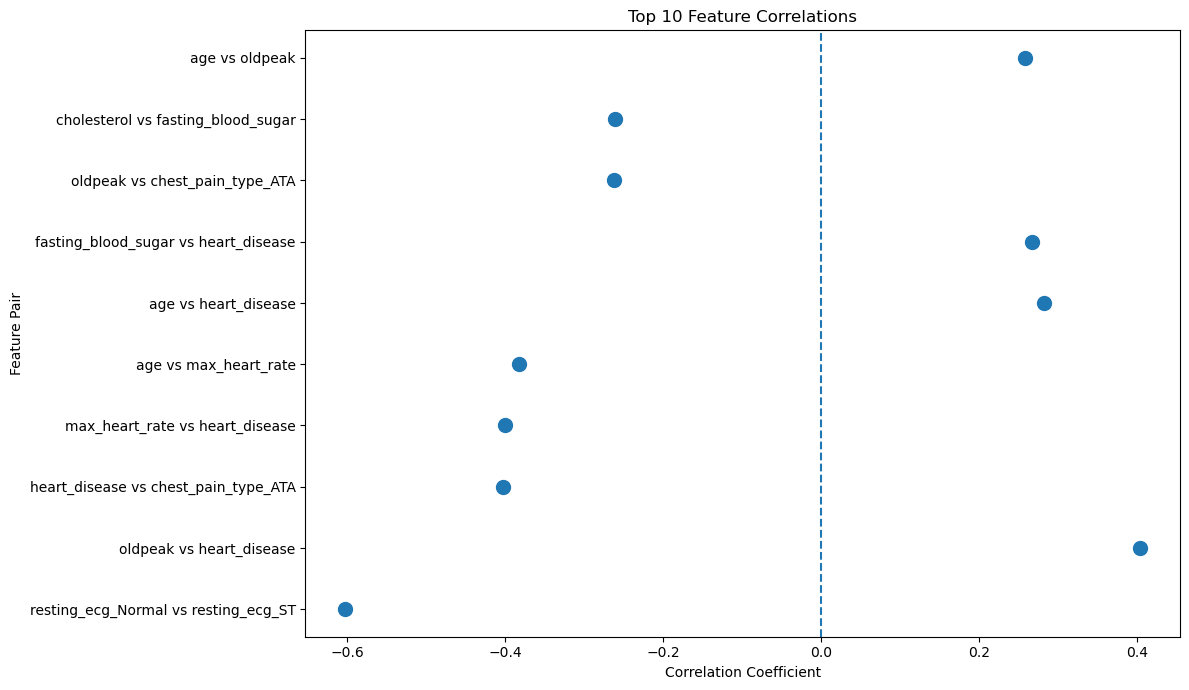

In [88]:
# Scatter plot of the 15 strongest correlations

top_10 = all_correlations.head(10).copy()

# Create feature-pair labels
top_10["Feature Pair"] = (
    top_10["Feature 1"] + " vs " + top_10["Feature 2"]
)

plt.figure(figsize=(12, 7))

plt.scatter(
    top_10["Correlation"],
    top_10["Feature Pair"],
    s=100
)

# Add a vertical reference line at zero
plt.axvline(0, linestyle="--")

plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature Pair")
plt.title("Top 10 Feature Correlations")

plt.tight_layout()
plt.show()

In [75]:
# Find highly correlated feature pairs
corr_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_correlations = (
    corr_pairs
    .stack()
    .reset_index()
)

high_correlations.columns = ["Feature 1", "Feature 2", "Correlation"]

high_correlations = high_correlations[
    high_correlations["Correlation"].abs() >= 0.60
].sort_values(
    by="Correlation",
    key=lambda x: x.abs(),
    ascending=False
)

print("Highly correlated feature pairs (|correlation| >= 0.60):")
display(high_correlations)

Highly correlated feature pairs (|correlation| >= 0.60):


,Feature 1,Feature 2,Correlation
65,resting_ecg_Normal,resting_ecg_ST,-0.602314


In [76]:
# Correlation with target
target_correlation = (
    correlation_matrix["heart_disease"]
    .drop("heart_disease")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Feature correlation with heart_disease:")
display(target_correlation.to_frame(name="Correlation"))

Feature correlation with heart_disease:


,Correlation
oldpeak,0.403951
chest_pain_type_ATA,-0.401924
max_heart_rate,-0.400421
age,0.282039
fasting_blood_sugar,0.267291
cholesterol,-0.232741
chest_pain_type_NAP,-0.212964
resting_bp,0.107589
resting_ecg_ST,0.102527
resting_ecg_Normal,-0.091580


In [65]:
# Feature importance Analysis
# Firstly, remove AgeGroup because it is derived from Age
X = hdp_encoded.drop(
    columns=["heart_disease", "age_group"],
    errors="ignore"
)

# Target variable
y = hdp_encoded["heart_disease"]

# Check that all predictor columns are numeric
print("Non-numeric columns:")
print(X.select_dtypes(exclude="number").columns.tolist())

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X, y)

# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance)

Non-numeric columns:
['sex', 'exercise_angina', 'st_slope']


,Feature,Importance
0,st_slope,0.203671
1,oldpeak,0.122610
2,max_heart_rate,0.119789
3,cholesterol,0.110942
4,exercise_angina,0.093021
5,age,0.084972
6,resting_bp,0.076114
7,chest_pain_type_ATA,0.053423
8,sex,0.040534
9,chest_pain_type_NAP,0.029085


#### Part 5 – Final Machine Learning Dataset

In [82]:
# Start from the encoded dataset
final_hdp = hdp_encoded.copy()

# Remove the engineered AgeGroup feature
# because it is derived from Age and may introduce redundancy
final_hdp = final_hdp.drop(
    columns=["age_group"],
    errors="ignore"
)

# Separate features and target
X_final = final_hdp.drop(columns=["heart_disease"])
y_final = final_hdp["heart_disease"]

# Combine them again for the final ML dataset
hdp_dataset = pd.concat(
    [X_final, y_final],
    axis=1
)

# Display final dataset
print("Final Machine Learning Dataset:")
display(hdp_dataset.head(10))

# Dataset dimensions
print("\nFinal dataset shape:")
print(hdp_dataset.shape)

Final Machine Learning Dataset:


,age,sex,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_angina,oldpeak,st_slope,chest_pain_type_ATA,chest_pain_type_NAP,chest_pain_type_TA,resting_ecg_Normal,resting_ecg_ST,heart_disease
0,-1.433140,1,0.410909,0.825070,-0.551341,1.382928,0,-0.832432,0,1,0,0,1,0,0
1,-0.478484,0,1.491752,-0.171961,-0.551341,0.754157,0,0.105664,1,0,1,0,1,0,1
2,-1.751359,1,-0.129513,0.770188,-0.551341,-1.525138,0,-0.832432,0,1,0,0,0,1,0
3,-0.584556,0,0.302825,0.139040,-0.551341,-1.132156,1,0.574711,1,0,0,0,1,0,1
4,0.051881,1,0.951331,-0.034755,-0.551341,-0.581981,0,-0.832432,0,0,1,0,1,0,0
5,-1.539213,1,-0.669935,1.282424,-0.551341,1.304332,0,-0.832432,0,0,1,0,1,0,0
6,-0.902775,0,-0.129513,0.349422,-0.551341,1.304332,0,-0.832432,0,1,0,0,1,0,0
7,0.051881,1,-1.210356,0.084157,-0.551341,0.203982,0,-0.832432,0,1,0,0,1,0,0
8,-1.751359,1,0.410909,0.075010,-0.551341,-0.267596,1,0.574711,1,0,0,0,1,0,1
9,-0.584556,0,-0.669935,0.779335,-0.551341,-0.660578,0,-0.832432,0,1,0,0,1,0,0



Final dataset shape:
(918, 15)


In [83]:
# Check data types to ensure dataset is ready for ML
print("Data types:")
display(hdp_dataset.dtypes)

# Check missing values
print("\nMissing values:")
display(hdp_dataset.isnull().sum())

# Check duplicates
print("\nDuplicate records:")
print(hdp_dataset.duplicated().sum())

# Check for non-numeric columns
print("\nNon-numeric columns:")
print(
    hdp_dataset.select_dtypes(exclude="number").columns.tolist()
)

# Check target distribution
print("\nTarget variable distribution:")
display(hdp_dataset["heart_disease"].value_counts())

# Final summary
print("\nFinal dataset shape:", hdp_dataset.shape)

Data types:


age                     float64
sex                    category
resting_bp              float64
cholesterol             float64
fasting_blood_sugar     float64
max_heart_rate          float64
exercise_angina        category
oldpeak                 float64
st_slope               category
chest_pain_type_ATA       int32
chest_pain_type_NAP       int32
chest_pain_type_TA        int32
resting_ecg_Normal        int32
resting_ecg_ST            int32
heart_disease             int64
dtype: object


Missing values:


age                    0
sex                    0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
chest_pain_type_ATA    0
chest_pain_type_NAP    0
chest_pain_type_TA     0
resting_ecg_Normal     0
resting_ecg_ST         0
heart_disease          0
dtype: int64


Duplicate records:
0

Non-numeric columns:
['sex', 'exercise_angina', 'st_slope']

Target variable distribution:


heart_disease
1    508
0    410
Name: count, dtype: int64


Final dataset shape: (918, 15)


In [85]:
# Saving my final test into a csv file
hdp_dataset.to_csv(
    "heart_disease_prediction_ml_ready.csv",
    index=False
)
print("Machine_learning_ready dataset saved successfully.")

Machine_learning_ready dataset saved successfully.
